In [97]:
#!!!!!!!!!!!!! ONLY RUN THIS CODE WHEN YOU DON'T HAVE THE CSV !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
#
#  from scipy.io import arff
# import pandas as pd

# # Load the arff file
# data, meta = arff.loadarff('fps-in-video-games.arff')

# # Convert to a pandas DataFrame
# df = pd.DataFrame(data)

# df.to_csv('fps-in-video-games.csv', index=False)

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor



In [99]:

df = pd.read_csv('fps-in-video-games.csv')
print(df.shape)
df.head()



(425833, 45)


,CpuName,CpuNumberOfCores,CpuNumberOfThreads,CpuBaseClock,CpuCacheL1,CpuCacheL2,CpuCacheL3,CpuDieSize,CpuFrequency,CpuMultiplier,...,GpuNumberOfShadingUnits,GpuNumberOfTMUs,GpuTextureRate,GpuNumberOfTransistors,GpuVulkan,GameName,GameResolution,GameSetting,Dataset,FPS
0,b'Intel Core i7-920',4.0,8.0,133.0,256.0,1024.0,8.0,0.000263,2666.0,20.0,...,2304.0,144.0,182300.0,5700.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',70.0
1,b'Intel Core i7-920',4.0,8.0,133.0,256.0,1024.0,8.0,0.000263,2666.0,20.0,...,2304.0,144.0,182300.0,5700.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',230.0
2,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,2560.0,160.0,277300.0,7200.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',250.0
3,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,2560.0,160.0,277300.0,7200.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',300.0
4,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,896.0,56.0,61600.0,2080.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',200.0


In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 425833 entries, 0 to 425832
Data columns (total 45 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CpuName                    425833 non-null  str    
 1   CpuNumberOfCores           425833 non-null  float64
 2   CpuNumberOfThreads         425833 non-null  float64
 3   CpuBaseClock               425833 non-null  float64
 4   CpuCacheL1                 425833 non-null  float64
 5   CpuCacheL2                 425833 non-null  float64
 6   CpuCacheL3                 420778 non-null  float64
 7   CpuDieSize                 223299 non-null  float64
 8   CpuFrequency               425833 non-null  float64
 9   CpuMultiplier              425833 non-null  float64
 10  CpuMultiplierUnlocked      425833 non-null  str    
 11  CpuProcessSize             425833 non-null  float64
 12  CpuTDP                     425833 non-null  float64
 13  CpuNumberOfTransistors     199794 non-nu

In [101]:
# Cek missing values
print(df.isnull().sum())

# Drop duplicate
df = df.drop_duplicates()

# Drop kolom yang tidak penting (opsional)
df = df.drop(columns=["CpuName", "GpuName"], errors='ignore')

CpuName                           0
CpuNumberOfCores                  0
CpuNumberOfThreads                0
CpuBaseClock                      0
CpuCacheL1                        0
CpuCacheL2                        0
CpuCacheL3                     5055
CpuDieSize                   202534
CpuFrequency                      0
CpuMultiplier                     0
CpuMultiplierUnlocked             0
CpuProcessSize                    0
CpuTDP                            0
CpuNumberOfTransistors       226039
CpuTurboClock                     0
GpuName                           0
GpuArchitecture                   0
GpuBandwidth                  15441
GpuBaseClock                      0
GpuBoostClock                     0
GpuBus nterface                   0
GpuNumberOfComputeUnits      357107
GpuDieSize                    11196
GpuDirectX                        0
GpuNumberOfExecutionUnits    412935
GpuFP32Performance               56
GpuMemoryBus                  15441
GpuMemorySize               

In [102]:
missing_percent = df.isnull().mean() * 100


cols_to_drop = missing_percent[missing_percent > 10].index
print("Dropped columns:", cols_to_drop)
df = df.drop(columns=cols_to_drop)

Dropped columns: Index(['CpuDieSize', 'CpuNumberOfTransistors', 'GpuNumberOfComputeUnits',
       'GpuNumberOfExecutionUnits'],
      dtype='str')


In [103]:
# Convert byte to string
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.replace("b'", "", regex=False).str.replace("'", "", regex=False)


In [104]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [105]:
df.info()

<class 'pandas.DataFrame'>
Index: 202935 entries, 0 to 425832
Data columns (total 39 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CpuNumberOfCores         202935 non-null  float64
 1   CpuNumberOfThreads       202935 non-null  float64
 2   CpuBaseClock             202935 non-null  float64
 3   CpuCacheL1               202935 non-null  float64
 4   CpuCacheL2               202935 non-null  float64
 5   CpuCacheL3               202935 non-null  float64
 6   CpuFrequency             202935 non-null  float64
 7   CpuMultiplier            202935 non-null  float64
 8   CpuMultiplierUnlocked    202935 non-null  str    
 9   CpuProcessSize           202935 non-null  float64
 10  CpuTDP                   202935 non-null  float64
 11  CpuTurboClock            202935 non-null  float64
 12  GpuArchitecture          202935 non-null  str    
 13  GpuBandwidth             202935 non-null  float64
 14  GpuBaseClock        

In [106]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [107]:
df = df.rename(columns={"GpuBus nterface": "GpuBusInterface"})

In [108]:
print(df.isnull().sum())


CpuNumberOfCores           0
CpuNumberOfThreads         0
CpuBaseClock               0
CpuCacheL1                 0
CpuCacheL2                 0
CpuCacheL3                 0
CpuFrequency               0
CpuMultiplier              0
CpuMultiplierUnlocked      0
CpuProcessSize             0
CpuTDP                     0
CpuTurboClock              0
GpuArchitecture            0
GpuBandwidth               0
GpuBaseClock               0
GpuBoostClock              0
GpuBusInterface            0
GpuDieSize                 0
GpuDirectX                 0
GpuFP32Performance         0
GpuMemoryBus               0
GpuMemorySize              0
GpuMemoryType              0
GpuOpenCL                  0
GpuOpenGL                  0
GpuPixelRate               0
GpuProcessSize             0
GpuNumberOfROPs            0
GpuShaderModel             0
GpuNumberOfShadingUnits    0
GpuNumberOfTMUs            0
GpuTextureRate             0
GpuNumberOfTransistors     0
GpuVulkan                  0
GameName      

In [109]:
Q1 = df["FPS"].quantile(0.25)
Q3 = df["FPS"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["FPS"] >= Q1 - 1.5*IQR) & (df["FPS"] <= Q3 + 1.5*IQR)]

In [110]:

le = LabelEncoder()

for col in df.select_dtypes(include=['object','string']).columns:
    df[col] = le.fit_transform(df[col])


In [111]:
X = df.drop("FPS", axis=1)
y = df["FPS"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


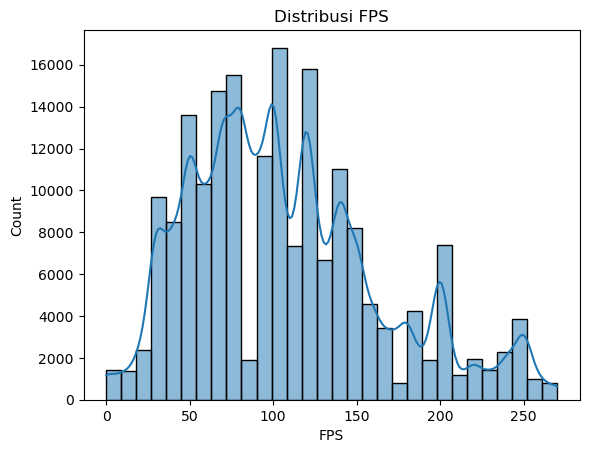

In [112]:
sns.histplot(df["FPS"], bins=30, kde=True)
plt.title("Distribusi FPS")
plt.show()

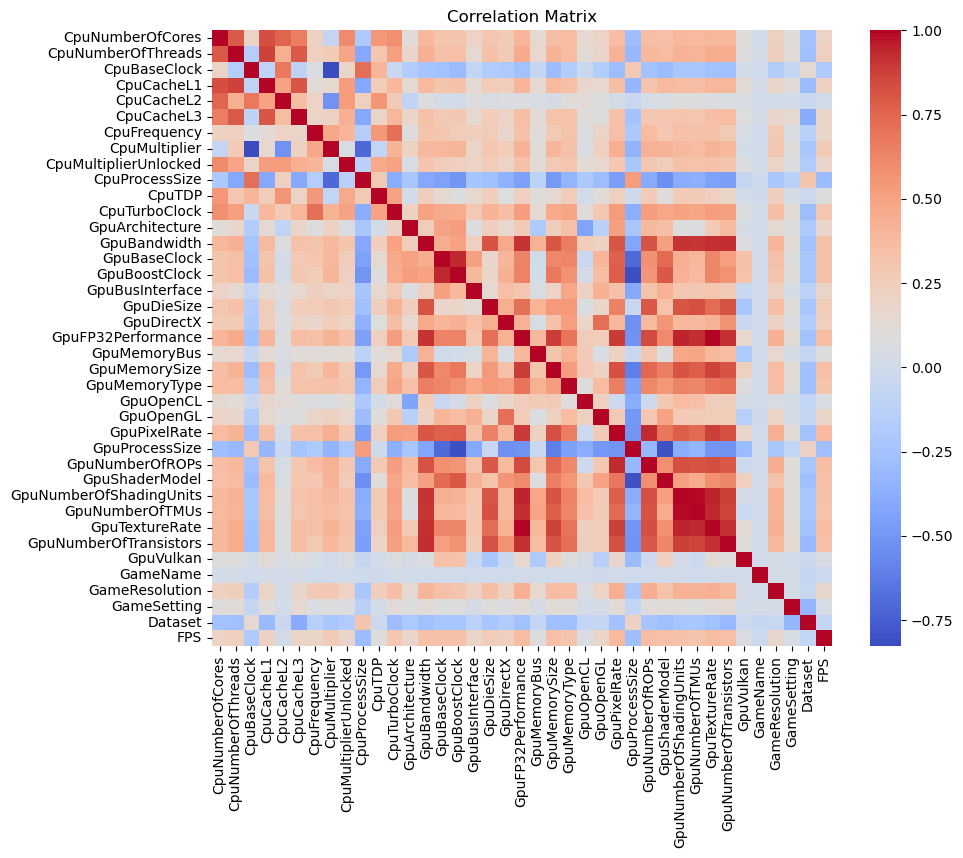

In [113]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

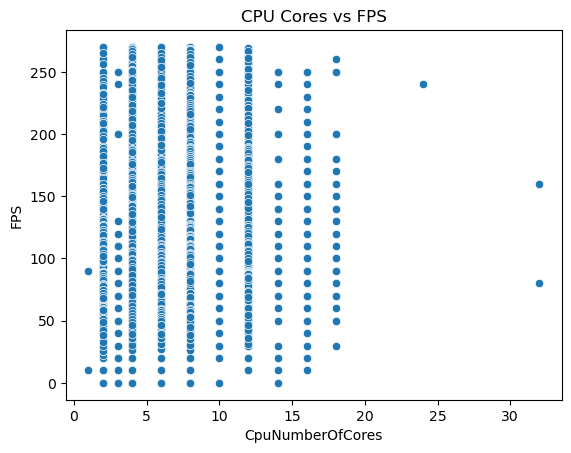

In [114]:
sns.scatterplot(x=df["CpuNumberOfCores"], y=df["FPS"])
plt.title("CPU Cores vs FPS")
plt.show()

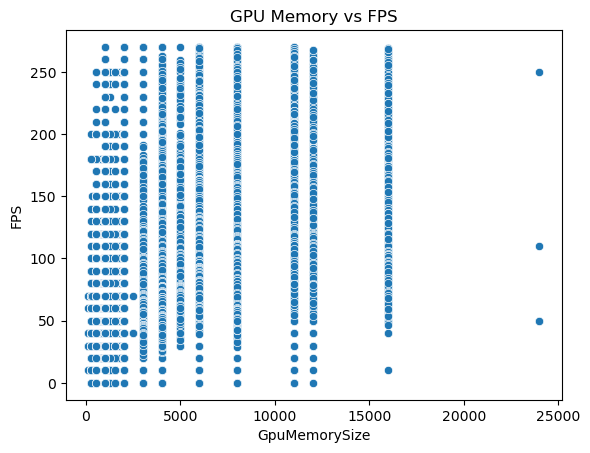

In [115]:
sns.scatterplot(x=df["GpuMemorySize"], y=df["FPS"])
plt.title("GPU Memory vs FPS")
plt.show()

<Axes: xlabel='GameResolution', ylabel='FPS'>

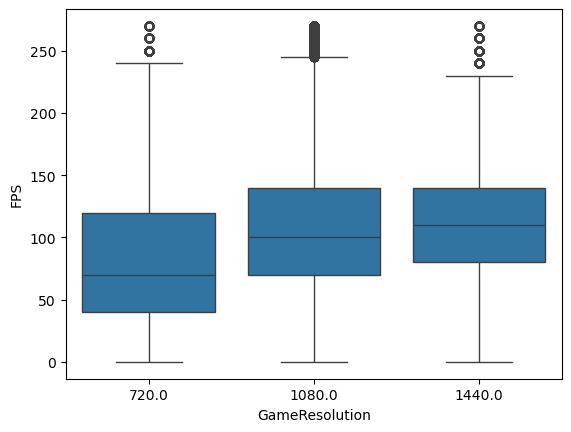

In [118]:
sns.boxplot(x=df["GameResolution"], y=df["FPS"])


In [119]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


In [120]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [121]:
def evaluate_model(y_true, y_pred):
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("R2  :", r2_score(y_true, y_pred))

In [122]:
print("Linear Regression")
evaluate_model(y_test, y_pred_lr)
print("Random Forest")
evaluate_model(y_test, y_pred_rf)

Linear Regression
RMSE: 51.65362393787531
MAE : 40.55503987464417
R2  : 0.18890891524162934
Random Forest
RMSE: 40.9709589735188
MAE : 29.17725479995846
R2  : 0.48970619782140856


In [123]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [124]:
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("Tuned Random Forest")
evaluate_model(y_test, y_pred_best)

Tuned Random Forest
RMSE: 38.73262088033678
MAE : 28.5531658021765
R2  : 0.5439401868500444


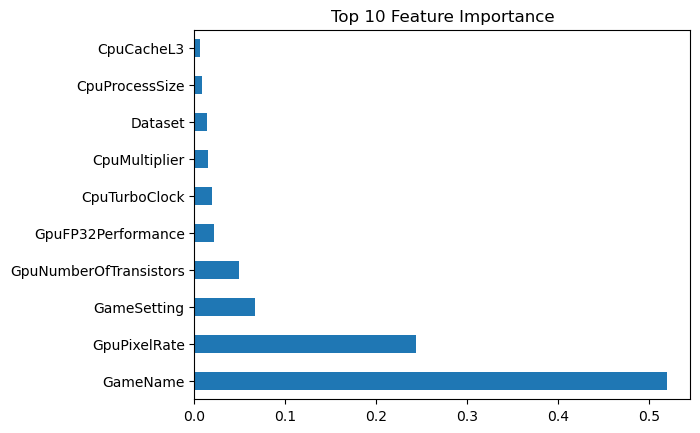

In [125]:
importances = best_rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importance")
plt.show()